<a href="https://colab.research.google.com/github/Diogocsantosz/analise_energia_renovaveis/blob/main/analise_energias_renovaveis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# APIs, energias renováveis e aprendizado de máquina

Este notebook coleta dados públicos da ANEEL e Open-Meteo, gera `aneel_classificacao_orange.csv` e `meteo_regressao_orange.csv`, e compara três modelos em cada tarefa. Execute as células na ordem. Os números e gráficos são produzidos pela execução, sem resultados inventados.


In [1]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score

SEED = 42
session = requests.Session()
retry = Retry(total=4, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
session.mount('https://', HTTPAdapter(max_retries=retry))


## 1. Classificação: fonte do empreendimento (ANEEL)

Fonte: [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel).


In [2]:
resource_id = '2f65a1b0-19b8-4360-8238-b34ab4693d55'
endpoint = 'https://dadosabertos.aneel.gov.br/api/3/action/datastore_search'
rows = []
limit = 1000
offset = 0
while True:
    response = session.get(endpoint, params={'resource_id': resource_id, 'limit': limit, 'offset': offset}, timeout=90)
    response.raise_for_status()
    payload = response.json()
    if not payload.get('success'):
        raise RuntimeError(payload.get('error', 'Falha na API ANEEL'))
    result = payload['result']
    batch = result['records']
    rows.extend(batch)
    offset += len(batch)
    if not batch or offset >= result['total']:
        break
print(f'Registros recebidos: {len(rows)}; total informado pela API: {result["total"]}')
assert len(rows) == result['total'], 'Consulta incompleta: revise a paginação.'
raw_aneel = pd.DataFrame(rows)
required = ['SigTipoGeracao', 'MdaPotenciaOutorgadaKw', 'NumCoordNEmpreendimento', 'NumCoordEEmpreendimento']
missing_fields = set(required) - set(raw_aneel.columns)
if missing_fields:
    raise ValueError(f'Campos ausentes na resposta ANEEL: {missing_fields}')
raw_aneel[required].head()


Registros recebidos: 25045; total informado pela API: 25045


,SigTipoGeracao,MdaPotenciaOutorgadaKw,NumCoordNEmpreendimento,NumCoordEEmpreendimento
0,PCH,"1400,00","-20,12479858","-43,87020250"
1,PCH,"3972,00","-20,13187300","-43,87693500"
2,PCH,"1440,00","-20,13754468","-43,89192620"
3,UHE,"100000,00","-29,06475278","-51,67494167"
4,CGH,"720,00","-27,82377500","-52,06999722"


In [3]:
source_map = {'UFV': 'Solar', 'EOL': 'Eólica', 'UHE': 'Hidráulica', 'PCH': 'Hidráulica', 'CGH': 'Hidráulica'}
aneel = raw_aneel[required].rename(columns={
    'SigTipoGeracao': 'fonte',
    'MdaPotenciaOutorgadaKw': 'potencia_kw',
    'NumCoordNEmpreendimento': 'latitude',
    'NumCoordEEmpreendimento': 'longitude',
}).copy()
aneel['fonte'] = aneel['fonte'].astype('string').str.strip().map(source_map)
def numeric_ptbr(column):
    txt = column.astype('string').str.strip()
    txt = txt.where(~txt.str.contains(',', na=False), txt.str.replace('.', '', regex=False).str.replace(',', '.', regex=False))
    return pd.to_numeric(txt, errors='coerce')
for field in ['potencia_kw', 'latitude', 'longitude']:
    aneel[field] = numeric_ptbr(aneel[field])
print('Linhas antes da limpeza:', len(aneel))
print('Valores ausentes antes da limpeza:')
print(aneel.isna().sum().to_string())
aneel = aneel.dropna(subset=['fonte', 'potencia_kw', 'latitude', 'longitude'])
aneel = aneel.loc[(aneel['potencia_kw'] > 0) & aneel['latitude'].between(-35, 6) & aneel['longitude'].between(-75, -30)].reset_index(drop=True)
print('Linhas após limpeza:', len(aneel))
print('Distribuição das classes:')
print(aneel['fonte'].value_counts().to_string())
print('Resumo das entradas:')
display(aneel[['potencia_kw', 'latitude', 'longitude']].describe().T)
assert aneel['fonte'].nunique() == 3, 'São necessárias três classes; confira a API e os filtros.'
aneel.to_csv('aneel_classificacao_orange.csv', index=False, encoding='utf-8-sig')


Linhas antes da limpeza: 25045
Valores ausentes antes da limpeza:
fonte          3058
potencia_kw       0
latitude          0
longitude         0
Linhas após limpeza: 21552
Distribuição das classes:
fonte
Solar         18589
Eólica         1507
Hidráulica     1456
Resumo das entradas:


,count,mean,std,min,25%,50%,75%,max
potencia_kw,21552.0,11911.667081,129530.810084,0.16,1.0,1.0,160.0,11233100.0
latitude,21552.0,-7.443207,7.858129,-33.722806,-13.85665,-2.470494,-1.915649,4.490711
longitude,21552.0,-50.013233,5.023824,-72.25002,-52.551327,-50.765222,-49.770884,-34.82389


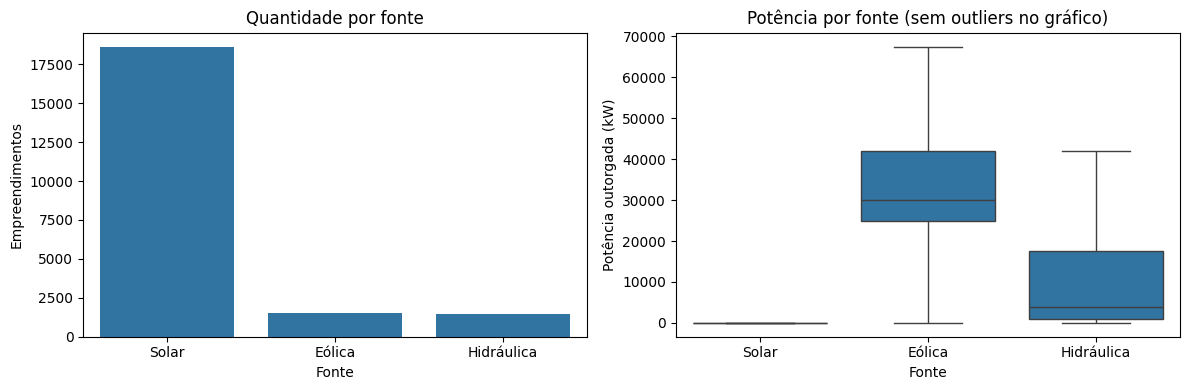

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=aneel, x='fonte', order=['Solar', 'Eólica', 'Hidráulica'], ax=axes[0])
axes[0].set(title='Quantidade por fonte', xlabel='Fonte', ylabel='Empreendimentos')
sns.boxplot(data=aneel, x='fonte', y='potencia_kw', order=['Solar', 'Eólica', 'Hidráulica'], showfliers=False, ax=axes[1])
axes[1].set(title='Potência por fonte (sem outliers no gráfico)', xlabel='Fonte', ylabel='Potência outorgada (kW)')
plt.tight_layout(); plt.show()


### Treino e comparação

Somente `potencia_kw`, `latitude` e `longitude` entram em `X`. A divisão 80/20 usa `random_state=42` e estratificação. As métricas multiclasses usam **média macro**: cada classe tem o mesmo peso. O escalonamento e a imputação ficam dentro dos pipelines, ajustados só no treino. A matriz tem linhas reais e colunas previstas.


Regressão logística — matriz (linhas reais / colunas previstas):
            Solar  Eólica  Hidráulica
Solar        3609      72          37
Eólica        186      93          23
Hidráulica     97      29         165

KNN (k=7) — matriz (linhas reais / colunas previstas):
            Solar  Eólica  Hidráulica
Solar        3657      22          39
Eólica         14     283           5
Hidráulica     25       3         263

Floresta aleatória — matriz (linhas reais / colunas previstas):
            Solar  Eólica  Hidráulica
Solar        3677      12          29
Eólica          8     291           3
Hidráulica     14       2         275



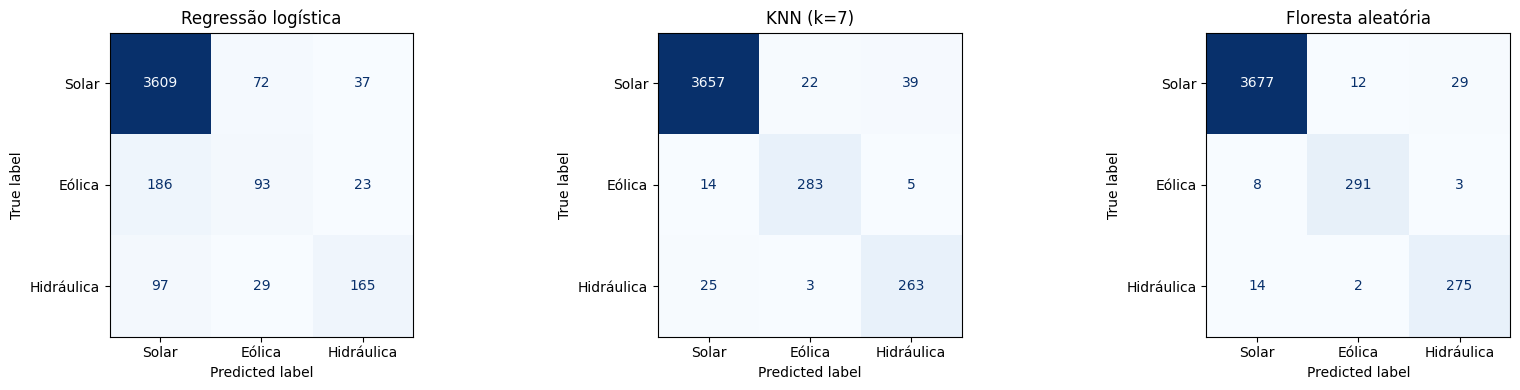

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Algoritmo,,,,
Regressão logística,0.897,0.713,0.615,0.654
KNN (k=7),0.975,0.922,0.941,0.931
Floresta aleatória,0.984,0.948,0.966,0.957


Mesmo teste estratificado 20%, seed 42; média macro para Precision, Recall e F1.


In [5]:
X = aneel[['potencia_kw', 'latitude', 'longitude']]
y = aneel['fonte']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
models_clf = {
    'Regressão logística': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED)),
    'KNN (k=7)': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
    'Floresta aleatória': make_pipeline(SimpleImputer(strategy='median'), RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=-1)),
}
labels = ['Solar', 'Eólica', 'Hidráulica']
result_clf = []
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, (name, model) in zip(axes, models_clf.items()):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    result_clf.append({'Algoritmo': name, 'Accuracy': accuracy_score(y_test, pred),
                       'Precision (macro)': precision_score(y_test, pred, average='macro', zero_division=0),
                       'Recall (macro)': recall_score(y_test, pred, average='macro', zero_division=0),
                       'F1 (macro)': f1_score(y_test, pred, average='macro', zero_division=0)})
    cm = confusion_matrix(y_test, pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name)
    print(f'{name} — matriz (linhas reais / colunas previstas):\n{pd.DataFrame(cm, index=labels, columns=labels)}\n')
plt.tight_layout(); plt.show()
clf_table = pd.DataFrame(result_clf).set_index('Algoritmo')
display(clf_table.round(3))
print('Mesmo teste estratificado 20%, seed 42; média macro para Precision, Recall e F1.')


In [6]:
best_clf = clf_table['F1 (macro)'].idxmax()
print(f'Maior F1 macro no teste: {best_clf} ({clf_table.loc[best_clf, "F1 (macro)"]:.3f}).')
best_cm = confusion_matrix(y_test, models_clf[best_clf].predict(X_test), labels=labels)
errors = [(best_cm[i, j], labels[i], labels[j]) for i in range(3) for j in range(3) if i != j]
count, actual, predicted = max(errors)
print(f'Confusão mais frequente desse modelo: {count} casos reais de {actual} previstos como {predicted}.')


Maior F1 macro no teste: Floresta aleatória (0.957).
Confusão mais frequente desse modelo: 29 casos reais de Solar previstos como Hidráulica.


## 2. Regressão: radiação solar em Petrolina (PE)

Fonte: [Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api). Coordenadas −9,39, −40,50; 01/04/2025 a 30/06/2025, fuso `America/Recife`. `shortwave_radiation` é a média da hora anterior em W/m², derivada de modelos/reanálise.


In [7]:
meteo_endpoint = 'https://archive-api.open-meteo.com/v1/archive'
meteo_params = {
    'latitude': -9.39, 'longitude': -40.50,
    'start_date': '2025-04-01', 'end_date': '2025-06-30',
    'hourly': 'temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,shortwave_radiation',
    'timezone': 'America/Recife',
}
response = session.get(meteo_endpoint, params=meteo_params, timeout=90)
response.raise_for_status()
payload = response.json()
if 'hourly' not in payload:
    raise RuntimeError(f'Sem dados horários: {payload}')
raw_meteo = pd.DataFrame(payload['hourly'])
required_meteo = ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
if set(required_meteo) - set(raw_meteo.columns):
    raise ValueError(f'Campos ausentes: {set(required_meteo) - set(raw_meteo.columns)}')
meteo = raw_meteo[required_meteo].rename(columns={
    'time': 'data_hora', 'temperature_2m': 'temperatura_c',
    'relative_humidity_2m': 'umidade_pct', 'cloud_cover': 'nuvens_pct',
    'wind_speed_10m': 'vento_kmh', 'shortwave_radiation': 'radiacao_w_m2',
}).copy()
meteo['data_hora'] = pd.to_datetime(meteo['data_hora'], errors='raise')
meteo['hora'] = meteo['data_hora'].dt.hour
meteo = meteo.loc[meteo['hora'].between(7, 17)].sort_values('data_hora').reset_index(drop=True)
print('Linhas:', len(meteo))
print('Ausentes por coluna:')
print(meteo.isna().sum().to_string())
assert meteo['data_hora'].is_unique and meteo['data_hora'].is_monotonic_increasing
assert len(meteo) == 91 * 11, 'Esperadas 11 horas por dia em 91 dias; revise a resposta da API.'
meteo.to_csv('meteo_regressao_orange.csv', index=False, encoding='utf-8-sig', date_format='%Y-%m-%dT%H:%M')
display(meteo.describe().T)


Linhas: 1001
Ausentes por coluna:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
radiacao_w_m2    0
hora             0


,count,mean,min,25%,50%,75%,max,std
data_hora,1001,2025-05-16 11:59:59.999999744,2025-04-01 07:00:00,2025-04-23 15:00:00,2025-05-16 12:00:00,2025-06-08 09:00:00,2025-06-30 17:00:00,NaN
temperatura_c,1001.0,28.885914,19.5,26.3,29.1,31.7,36.1,3.656514
umidade_pct,1001.0,50.544456,21.0,38.0,49.0,61.0,95.0,15.913965
nuvens_pct,1001.0,55.108891,0.0,19.0,54.0,98.0,100.0,37.851461
vento_kmh,1001.0,15.465435,2.3,12.2,15.4,19.0,30.1,4.923631
radiacao_w_m2,1001.0,472.854146,13.0,250.0,466.0,696.0,1002.0,256.36895
hora,1001.0,12.0,7.0,9.0,12.0,15.0,17.0,3.163858


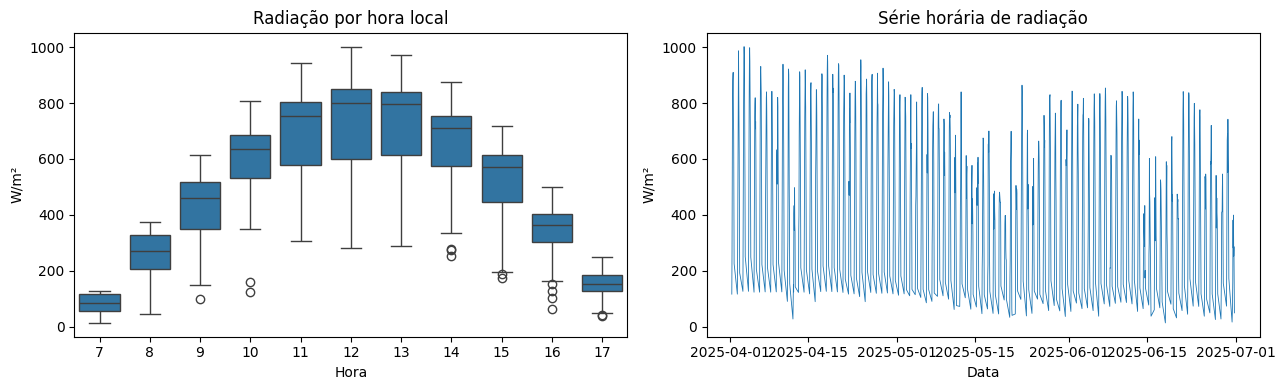

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=meteo, x='hora', y='radiacao_w_m2', ax=axes[0])
axes[0].set(title='Radiação por hora local', xlabel='Hora', ylabel='W/m²')
axes[1].plot(meteo['data_hora'], meteo['radiacao_w_m2'], linewidth=0.6)
axes[1].set(title='Série horária de radiação', xlabel='Data', ylabel='W/m²')
plt.tight_layout(); plt.show()


In [9]:
features = ['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']
meteo_valid = meteo.dropna(subset=['radiacao_w_m2']).reset_index(drop=True)
X_reg = meteo_valid[features]
y_reg = meteo_valid['radiacao_w_m2']
cut = int(len(meteo_valid) * 0.8)
Xr_train, Xr_test = X_reg.iloc[:cut], X_reg.iloc[cut:]
yr_train, yr_test = y_reg.iloc[:cut], y_reg.iloc[cut:]
print(f'Treino: {len(Xr_train)} horas ({meteo_valid.data_hora.iloc[0]} a {meteo_valid.data_hora.iloc[cut-1]})')
print(f'Teste: {len(Xr_test)} horas ({meteo_valid.data_hora.iloc[cut]} a {meteo_valid.data_hora.iloc[-1]})')
models_reg = {
    'Ridge': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), Ridge(alpha=1.0)),
    'Floresta aleatória': make_pipeline(SimpleImputer(strategy='median'), RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)),
    'Gradient boosting': make_pipeline(SimpleImputer(strategy='median'), HistGradientBoostingRegressor(random_state=SEED)),
}
result_reg = []
predictions = {}
for name, model in models_reg.items():
    model.fit(Xr_train, yr_train)
    pred = model.predict(Xr_test)
    predictions[name] = pred
    result_reg.append({'Algoritmo': name, 'MAE (W/m²)': mean_absolute_error(yr_test, pred),
                       'MSE ((W/m²)²)': mean_squared_error(yr_test, pred), 'R²': r2_score(yr_test, pred)})
reg_table = pd.DataFrame(result_reg).set_index('Algoritmo')
display(reg_table.round(2))


Treino: 800 horas (2025-04-01 07:00:00 a 2025-06-12 14:00:00)
Teste: 201 horas (2025-06-12 15:00:00 a 2025-06-30 17:00:00)


,MAE (W/m²),MSE ((W/m²)²),R²
Algoritmo,,,
Ridge,143.12,29226.17,0.38
Floresta aleatória,66.75,7287.11,0.84
Gradient boosting,60.55,6192.44,0.87


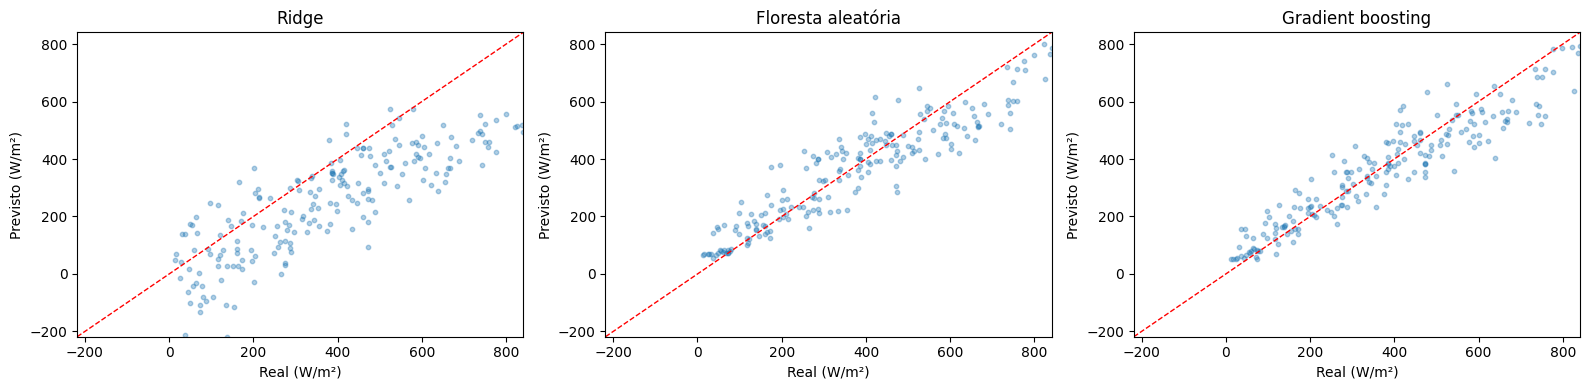

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
lo = min(yr_test.min(), *(p.min() for p in predictions.values()))
hi = max(yr_test.max(), *(p.max() for p in predictions.values()))
for ax, (name, pred) in zip(axes, predictions.items()):
    ax.scatter(yr_test, pred, s=10, alpha=.35)
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set(title=name, xlabel='Real (W/m²)', ylabel='Previsto (W/m²)', xlim=(lo, hi), ylim=(lo, hi))
plt.tight_layout(); plt.show()


**Interpretação após executar:** compare o menor MAE e MSE com o maior R² na tabela e descreva a dispersão em torno da diagonal do gráfico. A hora ajuda a capturar o ciclo diário de incidência solar; nuvens e condições meteorológicas também influenciam. Estimar a radiação horizontal de uma base meteorológica não equivale a estimar a eletricidade de um sistema fotovoltaico: seriam necessários, entre outros, área e orientação dos módulos, eficiência, temperatura dos módulos e perdas do inversor. O teste é posterior ao treino, mas ainda se restringe a três meses e uma cidade; não demonstra desempenho em outras épocas ou locais.


In [11]:
best_reg = reg_table['MAE (W/m²)'].idxmin()
print(f'Menor MAE no período de teste: {best_reg}, {reg_table.loc[best_reg, "MAE (W/m²)"]:.2f} W/m².')
print(f'MSE: {reg_table.loc[best_reg, "MSE ((W/m²)²)"]:.2f} (W/m²)²; R²: {reg_table.loc[best_reg, "R²"]:.3f}.')


Menor MAE no período de teste: Gradient boosting, 60.55 W/m².
MSE: 6192.44 (W/m²)²; R²: 0.868.
